In [1]:
import numpy as np
import scipy as sp
import cmath
#input params R,L,G,C,Z_L,V_in,w,Z_S,l
#calculate alpha,beta,gamma,ref_coeff,z_in,V,I,Z_0,power
#Z_S is assumed to be zero
#calculate gamma,alpha,beta
def calc_const(R,L,G,C,w):

  gamma=np.sqrt(complex(R,w*L)*complex(G,w*C))
  return gamma,gamma.real,gamma.imag

#calculate Z_0
def calc_Z0(R,L,G,C,w):
  return np.sqrt(complex(R,w*L)/complex(G,w*C))
#calculate ref_coeff at load
def calc_ref_coeff_load(R,L,G,C,w,Z_L,l):
  Z_0=calc_Z0(R,L,G,C,w)
  gamma=calc_const(R,L,G,C,w)[0]
  return ((Z_L-Z_0)/(Z_L+Z_0))*np.exp(-1*2*gamma*l)
#calc z_in
def calc_zin(R,L,G,C,w,Z_L,l):
  Z_0=calc_Z0(R,L,G,C,w)
  gamma=calc_const(R,L,G,C,w)[0]
  return Z_0*((Z_L+Z_0*np.tanh(gamma*l))/(Z_L*np.tanh(gamma*l)+Z_0))
#calc voltage at any point
def calc_vol(R,L,G,C,w,V_S,l,Z_L):

  gamma=calc_const(R,L,G,C,w)[0]
  V_in=V_S
  ref_coeff=calc_ref_coeff_load(R,L,G,C,w,Z_L,0)
  return V_in*(np.exp(gamma*l)+ref_coeff*np.exp(-1*gamma*l))
#calculate current at any point
def calc_current(R,L,G,C,w,V_S,l,Z_L):
  gamma=calc_const(R,L,G,C,w)[0]
  V_in=V_S
  ref_coeff=calc_ref_coeff_load(R,L,G,C,w,Z_L,0)
  Z_0=calc_Z0(R,L,G,C,w)
  return (V_in/Z_0)*(np.exp(gamma*l)-(ref_coeff)*np.exp(-1*gamma*l))

#calculate incident and delivered power
def calc_power(R,L,G,C,w,V_S,l,Z_L):

  return (0.5)*(calc_vol(R,L,G,C,w,V_S,l,Z_L)*np.conj(calc_current(R,L,G,C,w,V_S,l,Z_L)))








In [2]:

#test
import numpy as np

# Transmission line parameters
R = 0.1          # ohm/m
L = 250e-9       # H/m
G = 1e-3         # S/m
C = 100e-12      # F/m

# Frequency
f = 100e6        # 100 MHz
w = 2 * np.pi * f

# Load
Z_L = 75         # ohms

# Line length
l = 10           # m

# Source/input voltage
V_S = 1          # V



# 1. Propagation constant


gamma, alpha, beta = calc_const(R, L, G, C, w)

print("gamma =", gamma)
print("alpha =", alpha)
print("beta  =", beta)



# 2. Characteristic impedance


Z_0 = calc_Z0(R, L, G, C, w)

print("\nZ0 =", Z_0)



# 3. Reflection coefficient


ref_coeff = calc_ref_coeff_load(
    R, L, G, C, w, Z_L, l
)

print("\nReflection coefficient =", ref_coeff)
print("|Reflection coefficient| =", abs(ref_coeff))



# 4. Input impedance


Z_in = calc_zin(
    R, L, G, C, w, Z_L, l
)

print("\nZin =", Z_in)



# 5. Voltage

V = calc_vol(
    R, L, G, C, w, V_S, l, Z_L
)

print("\nVoltage =", V)



# 6. Current


I = calc_current(
    R, L, G, C, w, V_S, l, Z_L
)

print("\nCurrent =", I)



# 7. Power


power = calc_power(
    R, L, G, C, w, V_S, l, Z_L
)

print("\nPower =", power)

gamma = (0.025999241392137946+3.14168431922151j)
alpha = 0.025999241392137946
beta  = 3.14168431922151

Z0 = (49.99538061076874+0.3819104171766383j)

Reflection coefficient = (0.1189214230097662-0.0023979123592152837j)
|Reflection coefficient| = 0.11894559611162671

Zin = (63.49290748041348+0.17613954403436521j)

Voltage = (1.4511540905610343-0.0017796924615057156j)

Current = (0.022855119462634743-9.143356341487446e-05j)

Power = (0.01658323141104353+4.600455287480159e-05j)


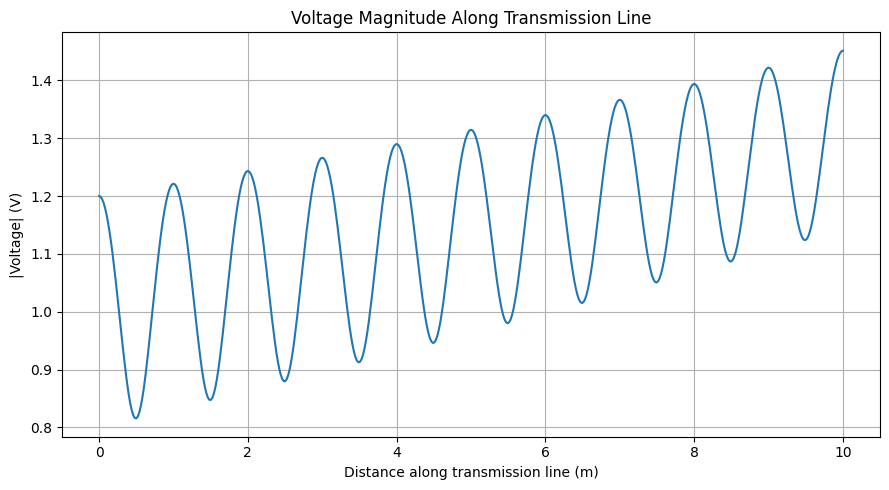

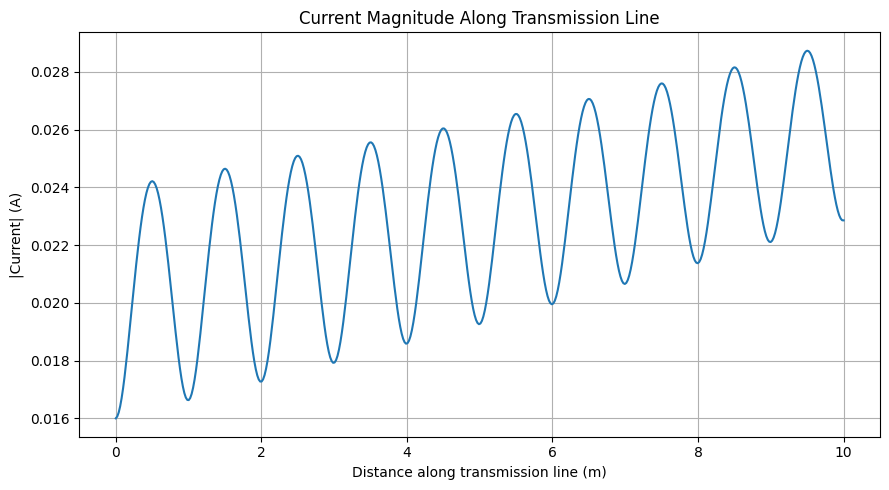

In [3]:
#test and graphs
import numpy as np
import matplotlib.pyplot as plt



# TEST PARAMETERS


R = 0.1          # ohm/m
L = 250e-9       # H/m
G = 1e-3         # S/m
C = 100e-12      # F/m

f = 100e6        # 100 MHz
w = 2 * np.pi * f

Z_L = 75         # ohm
V_S = 1          # V

l = 10           # transmission line length in m



# DISTANCE ALONG THE TRANSMISSION LINE

x_values = np.linspace(0, l, 500)



# CALCULATE VOLTAGE AND CURRENT


voltage = []
current = []

for x in x_values:

    V = calc_vol(
        R, L, G, C, w,
        V_S, x, Z_L
    )

    I = calc_current(
        R, L, G, C, w,
        V_S, x, Z_L
    )

    voltage.append(abs(V))
    current.append(abs(I))


voltage = np.array(voltage)
current = np.array(current)



# VOLTAGE PLOT


plt.figure(figsize=(9, 5))

plt.plot(x_values, voltage)

plt.xlabel("Distance along transmission line (m)")
plt.ylabel("|Voltage| (V)")
plt.title("Voltage Magnitude Along Transmission Line")

plt.grid(True)
plt.tight_layout()
plt.show()



# CURRENT PLOT


plt.figure(figsize=(9, 5))

plt.plot(x_values, current)

plt.xlabel("Distance along transmission line (m)")
plt.ylabel("|Current| (A)")
plt.title("Current Magnitude Along Transmission Line")

plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
#ml_model
#i will be using a neural network which is physics informed
#create dataset
import numpy as np
import pandas as pd

np.random.seed(42)

N = 100

# Fixed parameters
Z_L = 75
V_S = 1
l = 10

data = []

for i in range(N):


    # Random transmission line parameters


    R = np.random.uniform(0.01, 0.5)          # ohm/m
    L = np.random.uniform(100e-9, 500e-9)      # H/m
    G = np.random.uniform(1e-5, 5e-3)          # S/m
    C = np.random.uniform(50e-12, 200e-12)     # F/m

    # Frequency
    f = np.random.uniform(10e6, 500e6)         # Hz
    w = 2 * np.pi * f

    # Position
    x = np.random.uniform(0, l)



    gamma, alpha, beta = calc_const(
        R, L, G, C, w
    )



    V = calc_vol(
        R, L, G, C,
        w,
        V_S,
        x,
        Z_L
    )



    I = calc_current(
        R, L, G, C,
        w,
        V_S,
        x,
        Z_L
    )



    data.append([
        R,
        L,
        G,
        C,
        f,
        x,

        gamma.real,
        gamma.imag,

        V.real,
        V.imag,

        I.real,
        I.imag
    ])


# Create dataframe

df = pd.DataFrame(
    data,
    columns=[
        "R",
        "L",
        "G",
        "C",
        "frequency",
        "position",

        "gamma_real",
        "gamma_imag",

        "voltage_real",
        "voltage_imag",

        "current_real",
        "current_imag"
    ]
)


# Display dataset
print(df)

# Save dataset
df.to_csv(
    "transmission_line_dataset_100.csv",
    index=False
)

print("\nDataset saved successfully.")
print("Number of samples:", len(df))

           R             L         G             C     frequency  position  \
0   0.193525  4.802857e-07  0.003663  1.397988e-10  8.644913e+07  1.559945   
1   0.038461  4.464705e-07  0.003010  1.562109e-10  2.008640e+07  9.699099   
2   0.417897  1.849356e-07  0.000917  7.751068e-11  1.590787e+08  5.247564   
3   0.221653  2.164917e-07  0.003063  7.092408e-11  1.531509e+08  3.663618   
4   0.233474  4.140704e-07  0.001006  1.271352e-10  3.002831e+08  0.464504   
..       ...           ...       ...           ...           ...       ...   
95  0.261855  4.134612e-07  0.001989  1.433130e-10  4.325582e+08  9.495206   
96  0.082066  4.706351e-07  0.002466  8.873666e-11  2.349765e+08  9.800326   
97  0.251383  2.315006e-07  0.003171  8.602184e-11  4.717303e+07  1.288797   
98  0.072742  1.607611e-07  0.000703  1.461312e-10  9.912124e+07  3.456673   
99  0.449426  2.895847e-07  0.003341  7.584798e-11  1.042216e+08  0.408686   

    gamma_real  gamma_imag  voltage_real  voltage_imag  current

          R             L         G             C     frequency  gamma_real  \
0  0.193525  4.802857e-07  0.003663  1.397988e-10  8.644913e+07    0.108961   
1  0.086437  1.232334e-07  0.004332  1.401673e-10  3.569556e+08    0.065684   
2  0.020086  4.879639e-07  0.004164  8.185087e-11  9.909423e+07    0.160747   
3  0.099868  2.216969e-07  0.002629  1.147918e-10  1.527023e+08    0.058890   
4  0.309808  1.557975e-07  0.001468  1.049543e-10  2.334743e+08    0.032296   

   gamma_imag  
0    4.452094  
1    9.321621  
2    3.938172  
3    4.840500  
4    5.932025  

Dataset shape:
(1000, 7)

Training samples: 800
Testing samples : 200

Model:
neural_network(
  (fc1): Linear(in_features=5, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=128, bias=True)
  (fc4): Linear(in_features=128, out_features=2, bias=True)
)
Epoch     0 | Total Loss: 2.287974e+02 | Data Loss: 1.071675e+00 | Physics Loss: 2.27725

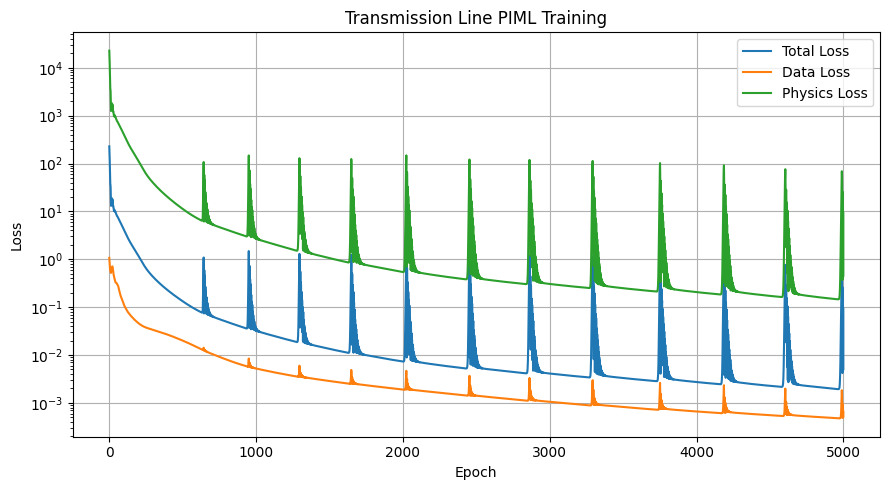

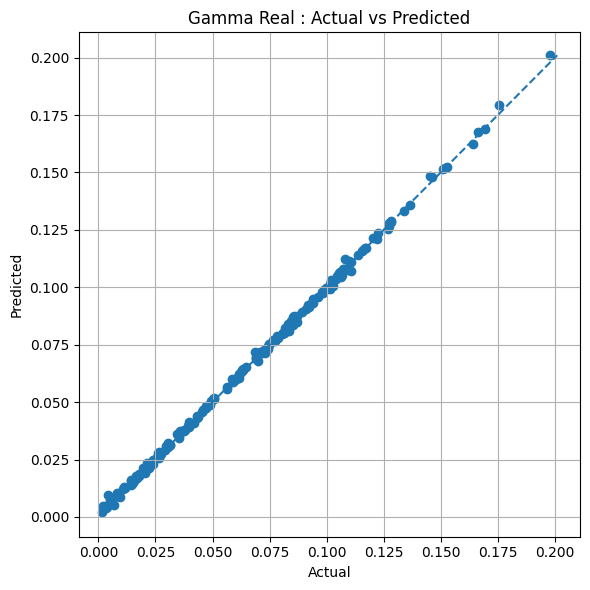

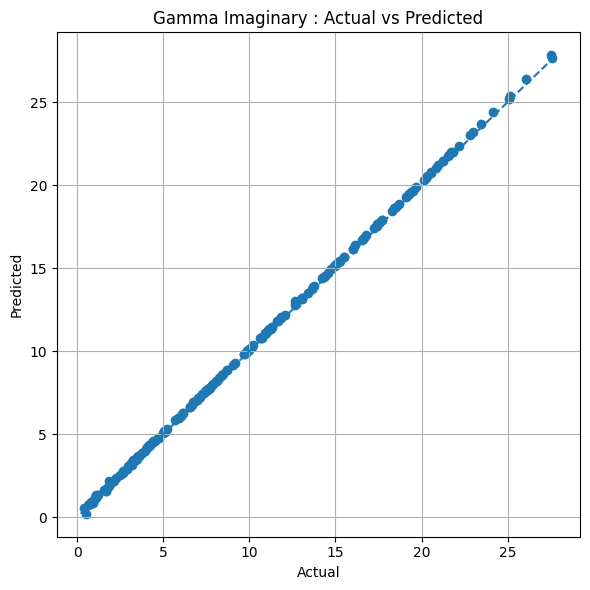

In [23]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score



np.random.seed(42)
torch.manual_seed(42)




N = 1000

data = []

for i in range(N):


    R = np.random.uniform(0.01, 0.5)
    L = np.random.uniform(100e-9, 500e-9)
    G = np.random.uniform(1e-5, 5e-3)
    C = np.random.uniform(50e-12, 200e-12)


    f = np.random.uniform(10e6, 500e6)

    # Angular frequency
    w = 2 * np.pi * f

    # Propagation constant
    gamma = np.sqrt(
        (R + 1j * w * L) *
        (G + 1j * w * C)
    )

    gamma_real = gamma.real
    gamma_imag = gamma.imag

    data.append([
        R,
        L,
        G,
        C,
        f,
        gamma_real,
        gamma_imag
    ])



columns = [
    "R",
    "L",
    "G",
    "C",
    "frequency",
    "gamma_real",
    "gamma_imag"
]

df = pd.DataFrame(
    data,
    columns=columns
)

print(df.head())

print("\nDataset shape:")
print(df.shape)


# Save dataset
df.to_csv(
    "transmission_line_gamma_dataset.csv",
    index=False
)




input_columns = [
    "R",
    "L",
    "G",
    "C",
    "frequency"
]

target_columns = [
    "gamma_real",
    "gamma_imag"
]

X = df[input_columns].values
Y = df[target_columns].values




X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    Y,
    test_size=0.20,
    random_state=42
)

print("\nTraining samples:", len(X_train))
print("Testing samples :", len(X_test))




input_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = input_scaler.fit_transform(
    X_train
)

X_test_scaled = input_scaler.transform(
    X_test
)

Y_train_scaled = target_scaler.fit_transform(
    Y_train
)

Y_test_scaled = target_scaler.transform(
    Y_test
)


# Convert to PyTorch tensors

X_train_tensor = torch.tensor(
    X_train_scaled,
    dtype=torch.float32
)

Y_train_tensor = torch.tensor(
    Y_train_scaled,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_scaled,
    dtype=torch.float32
)

Y_test_tensor = torch.tensor(
    Y_test_scaled,
    dtype=torch.float32
)




class neural_network(nn.Module):

    def __init__(self):

        super(neural_network, self).__init__()

        self.fc1 = nn.Linear(5, 128)
        self.fc2 = nn.Linear(128, 128)
        self.fc3 = nn.Linear(128, 128)
        self.fc4 = nn.Linear(128, 2)

    def forward(self, x):

        x = torch.tanh(self.fc1(x))
        x = torch.tanh(self.fc2(x))
        x = torch.tanh(self.fc3(x))

        x = self.fc4(x)

        return x



model = neural_network()

print("\nModel:")
print(model)




optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)




def physics_loss(model, X_scaled):



    pred_scaled = model(X_scaled)




    target_mean = torch.tensor(
        target_scaler.mean_,
        dtype=torch.float32
    )

    target_std = torch.tensor(
        target_scaler.scale_,
        dtype=torch.float32
    )

    pred = (
        pred_scaled * target_std
        + target_mean
    )




    gamma_real = pred[:, 0:1]
    gamma_imag = pred[:, 1:2]




    input_mean = torch.tensor(
        input_scaler.mean_,
        dtype=torch.float32
    )

    input_std = torch.tensor(
        input_scaler.scale_,
        dtype=torch.float32
    )

    X_physical = (
        X_scaled * input_std
        + input_mean
    )




    R = X_physical[:, 0:1]
    L = X_physical[:, 1:2]
    G = X_physical[:, 2:3]
    C = X_physical[:, 3:4]
    f = X_physical[:, 4:5]

    w = 2 * torch.pi * f





    residual_real = (
        gamma_real**2
        - gamma_imag**2
        - (
            R * G
            - w**2 * L * C
        )
    )

    residual_imag = (
        2 * gamma_real * gamma_imag
        - w * (
            R * C
            + L * G
        )
    )


    # Physics loss

    loss_real = torch.mean(
        residual_real**2
    )

    loss_imag = torch.mean(
        residual_imag**2
    )

    total_physics_loss = (
        loss_real + loss_imag
    )

    return total_physics_loss




epochs = 5000

lambda_physics = 0.01

total_losses = []
data_losses = []
physics_losses = []


for epoch in range(epochs):

    model.train()

    optimizer.zero_grad()




    prediction = model(
        X_train_tensor
    )




    data_loss = torch.mean(
        (
            prediction
            - Y_train_tensor
        )**2
    )




    p_loss = physics_loss(
        model,
        X_train_tensor
    )




    total_loss = (
        data_loss
        + lambda_physics * p_loss
    )



    total_loss.backward()

    optimizer.step()




    total_losses.append(
        total_loss.item()
    )

    data_losses.append(
        data_loss.item()
    )

    physics_losses.append(
        p_loss.item()
    )




    if epoch % 500 == 0:

        print(
            f"Epoch {epoch:5d} | "
            f"Total Loss: {total_loss.item():.6e} | "
            f"Data Loss: {data_loss.item():.6e} | "
            f"Physics Loss: {p_loss.item():.6e}"
        )



model.eval()

with torch.no_grad():

    prediction_scaled = model(
        X_test_tensor
    ).numpy()




prediction = target_scaler.inverse_transform(
    prediction_scaled
)


actual = Y_test




mse = mean_squared_error(
    actual,
    prediction
)

rmse = np.sqrt(mse)

mae = mean_absolute_error(
    actual,
    prediction
)

r2 = r2_score(
    actual,
    prediction
)


print("\n")
print("==============================")
print("       TEST RESULTS")
print("==============================")

print(f"Test MSE  : {mse:.6e}")
print(f"Test RMSE : {rmse:.6e}")
print(f"Test MAE  : {mae:.6e}")
print(f"Test R²   : {r2:.6f}")




gamma_names = [
    "Gamma Real",
    "Gamma Imaginary"
]


print("\n")
print("==============================")
print("   GAMMA COMPONENT RESULTS")
print("==============================")


for i, name in enumerate(gamma_names):

    mse_i = mean_squared_error(
        actual[:, i],
        prediction[:, i]
    )

    rmse_i = np.sqrt(mse_i)

    mae_i = mean_absolute_error(
        actual[:, i],
        prediction[:, i]
    )

    r2_i = r2_score(
        actual[:, i],
        prediction[:, i]
    )

    print(f"\n{name}")

    print(
        f"RMSE = {rmse_i:.6e}"
    )

    print(
        f"MAE  = {mae_i:.6e}"
    )

    print(
        f"R²   = {r2_i:.6f}"
    )




plt.figure(figsize=(9, 5))

plt.plot(
    total_losses,
    label="Total Loss"
)

plt.plot(
    data_losses,
    label="Data Loss"
)

plt.plot(
    physics_losses,
    label="Physics Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "Transmission Line PIML Training"
)

plt.yscale("log")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.show()




for i, name in enumerate(gamma_names):

    plt.figure(figsize=(6, 6))

    plt.scatter(
        actual[:, i],
        prediction[:, i]
    )

    minimum = min(
        actual[:, i].min(),
        prediction[:, i].min()
    )

    maximum = max(
        actual[:, i].max(),
        prediction[:, i].max()
    )

    plt.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    plt.xlabel("Actual")

    plt.ylabel("Predicted")

    plt.title(
        name + " : Actual vs Predicted"
    )

    plt.grid(True)

    plt.tight_layout()

    plt.show()